<a href="https://colab.research.google.com/github/hamoun-enayati/Cat-Dog-Classifier-CNN/blob/main/cat_dog_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os


In [2]:
import kagglehub


path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [12]:
train_path = path + '/training_set/training_set'
test_path = path + '/test_set/test_set'

In [36]:
len(os.listdir(test_path + '/cats'))

1012

In [14]:
print(os.listdir(train_path))
print(os.listdir(test_path))

['dogs', 'cats']
['dogs', 'cats']


In [15]:
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
EPOCHS = 60

In [16]:
train_datagen = ImageDataGenerator(
    rescale = 1.0/255,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    horizontal_flip = True,
    zoom_range = 0.2,
    validation_split = 0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    subset = 'training'
)

Found 6404 images belonging to 2 classes.


In [17]:
train_generator.class_indices

{'cats': 0, 'dogs': 1}

In [18]:
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    subset = 'validation'
)


Found 1601 images belonging to 2 classes.


In [19]:
test_datagen = ImageDataGenerator(
    rescale=1.0/255
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2023 images belonging to 2 classes.


In [27]:
model = Sequential([
    layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3), activation = 'relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3), activation = 'relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation = 'relu'),
    layers.Dense(2, activation = 'softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,690 (72.61 MB)

 Trainable params: 19,034,690 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy'])

In [30]:
history = model.fit(train_generator, epochs = EPOCHS, validation_data = validation_generator)

Epoch 1/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 101s 467ms/step - accuracy: 0.5265 - loss: 0.7142 - val_accuracy: 0.5609 - val_loss: 0.6887
Epoch 2/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 60s 297ms/step - accuracy: 0.5381 - loss: 0.6881 - val_accuracy: 0.5753 - val_loss: 0.6794
Epoch 3/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 58s 287ms/step - accuracy: 0.5759 - loss: 0.6787 - val_accuracy: 0.5684 - val_loss: 0.6788
Epoch 4/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 58s 288ms/step - accuracy: 0.6081 - loss: 0.6621 - val_accuracy: 0.6240 - val_loss: 0.6458
Epoch 5/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 59s 293ms/step - accuracy: 0.6188 - loss: 0.6558 - val_accuracy: 0.6371 - val_loss: 0.6423
Epoch 6/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 59s 296ms/step - accuracy: 0.6587 - loss: 0.6204 - val_accuracy: 0.6608 - val_loss: 0.6189
Epoch 7/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 59s 296ms/step - accuracy: 0.6572 - loss: 0.6140 - val_accuracy: 0.6633 - val_loss: 0.6046
Epoch 8/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 59s 294ms/step - accuracy: 0.6916 - loss: 

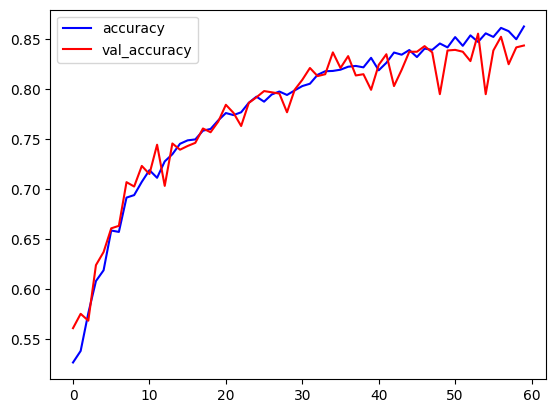

In [31]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color = 'blue', label = 'accuracy')
plt.plot(history.history['val_accuracy'], color = 'red', label = 'val_accuracy')
plt.legend()
plt.show()

In [32]:
model.evaluate(test_generator)

64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 205ms/step - accuracy: 0.8705 - loss: 0.3151


[0.31510239839553833, 0.8704893589019775]

In [33]:
model.save('cat_dog_classifier.keras')

In [34]:
model.save_weights('cat_dog_classifier.weights.h5')